# Tarefa

## Avaliações e análises de obras literárias em inglês disponíveis no Projeto Gutenberg

Cada grupo (4-5 componentes) deverá realizar as seguintes tarefas, a partir de corpus pré-definidos do Projeto Gutenberg.

- Encontrar e carregar o corpus de texto indicado para seu grupo.
- Realizar o pré-processamento do texto, executando as etapas que achar necessárias.
- Calcular e exibir graficamente a distribuição de frequência das vinte palavras mais comuns, excluindo *stopwords*.
- Apresentar graficamente os 10 bigramas mais comuns do texto processado.
- Apresentar graficamente os dez trigramas mais comuns do texto processado.
- Escolher três palavras, três bigramas e três trigramas representativos e aplicar uma análise de concordância e similaridade. Justifique suas escolhas e apresente o resultado.
- Você conseguiria estabelecer uma relação entre cada um dos três grupos de análises do item anterior e o contexto da obra analisada? Em outras palavras: as palavras, bigramas e trigramas escolhiodos, a partir dos mais representativos, realmente representam a obra literária onde aparecem. Justifiquem as respostas.

**A apresentação dos resultados de cada grupo deverá ser feita na aula do dia 07/10/2025, após a vista de prova. O formato de apresentação é livre e deverão ser apresentados, pelo menos, as informações pedidas acima. Máximo de 10 minutos por grupo. O trabalho também será entregue no mesmo dia, via e-mail, para `cassius.figueiredo@professores.ibmec.edu.br`.**


## **Corpora**

- 1) **Frankenstein**, Mary Wollstonecraft Shelley
- 2) **Moby Dick**, Herman Melville
- 3) **Alice's Adventures in Wonderland**, Lewis Carroll
- 4) **The Strange Case of Dr. Jekyll and Mr. Hyde**, Robert Louis Stevenson
- 5) **Dracula**, Bram Stoker
- 6) **The Adventures of Sherlock Holmes**, Arthur Conan Doyle
- 7) **A Christmas Carol**, Charles Dickens
- 8) **The Wonderful Wizard of Oz**, L. Frank Baum
- 9) **Gulliver's Travels**, Jonathan Swift
- 10) **The War of the Worlds**, H. G. Wells
- 11) **Treasure Island**, Robert Louis Stevenson
- 12) **Don Quixote**, Miguel de Cervantes Saavedra
- 13) **The Life and Adventures of Robinson Crusoe**, Daniel Defoe
- 14) **Twenty Thousand Leagues under the Sea**, Jules Verne
- 15) **Around the World in Eighty Days**, Jules Verne
- 16) **A Journey to the Centre of the Earth**, Jules Verne


## **Lista de grupos e livros escolhidos**

- GRUPO 01 (Breno França, Isabella, Fabiano, Thiago Brandão, João Pedro Menezes) (6)
- GRUPO 02 (Breno Souza, Mateus Padilha, Gustavo Raia, Ian Esteves, Brenda) (4)
- GRUPO 03 (Gabriel Franklin, João Gabriel, Rafael, Thais, André) (10)
- GRUPO 04 (Fernanda, Juliana, Maria, Larissa, João Araújo) (3)
- GRUPO 05 (Ivo, Pedro, Mateus Norcia, Rodrigo, Matheus Cocenzo) (8)
- GRUPO 06 (Daniel, João Vitor, Luis Pastura, Thiago Borsoni, Matheus Peçanha) (11)
- GRUPO 07 (Amanda, Beatriz, Guilherme Duran, Laura, Gabriel Mendes) (12)


# Solução

## Configuração Básica

### Importação das Bibliotecas Necessárias

In [ ]:
# You may need to run these once in your environment (e.g., Colab, Jupyter, etc.)
# !pip install requests nltk matplotlib

import requests
import re
import math
import nltk
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import bigrams, trigrams

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


### Importação do Livro - O Médico e o Monstro (_The Strange Case of Dr. Jekyll and Mr. Hyde_)

In [ ]:
# URL do Livro Disponível no Site do Projeto Gutenberg
url = "https://www.gutenberg.org/files/42/42-0.txt"

response = requests.get(url)
text = response.text[1509:142685]

# Removendo Prefácio, Índice e Dedicatória
print(text)

STORY OF THE DOOR


Mr. Utterson the lawyer was a man of a rugged countenance, that was
never lighted by a smile; cold, scanty and embarrassed in discourse;
backward in sentiment; lean, long, dusty, dreary, and yet somehow
lovable. At friendly meetings, and when the wine was to his taste,
something eminently human beaconed from his eye; something indeed which
never found its way into his talk, but which spoke not only in these
silent symbols of the after-dinner face, but more often and loudly in
the acts of his life. He was austere with himself; drank gin when he
was alone, to mortify a taste for vintages; and though he enjoyed the
theatre, had not crossed the doors of one for twenty years. But he had
an approved tolerance for others; sometimes wondering, almost with
envy, at the high pressure of spirits involved in their misdeeds; and
in any extremity inclined to help rather than to reprove. “I incline to
Cain’s heresy,” he used to say quaintly: “I let my brother go to the
devil in hi

## Pré-Processamento de Texto

In [ ]:
# Convertendo Texto para Lowercase
text = text.lower()

# Limpeza de Dados (Mantém apenas Letras e Espaços)
text = re.sub(r'[^a-z\s]', '', text)

# Tokenização
tokens = word_tokenize(text)

# Exemplo com as Stopwords
print("Primeiras 5 palavras (com stopwords):\n\n" + "\n".join([str(tok) for tok in tokens[:5]]))

Primeiras 5 palavras (com stopwords):

story
of
the
door
mr


### Remoção de Stopwords (Inglês)

In [ ]:
# Definindo as Stopwords (Padrão)
stop_words = set(stopwords.words("english"))

# Remoção de Stopwords
filtered_tokens = [word for word in tokens if word not in stop_words]

# Exemplo sem as Stopwords
print("Primeiras 5 palavras (sem stopwords):\n\n" + "\n".join([str(tok) for tok in filtered_tokens[:5]]))

Primeiras 5 palavras (sem stopwords):

story
door
mr
utterson
lawyer


## Plots

### Distribuição de Frequência

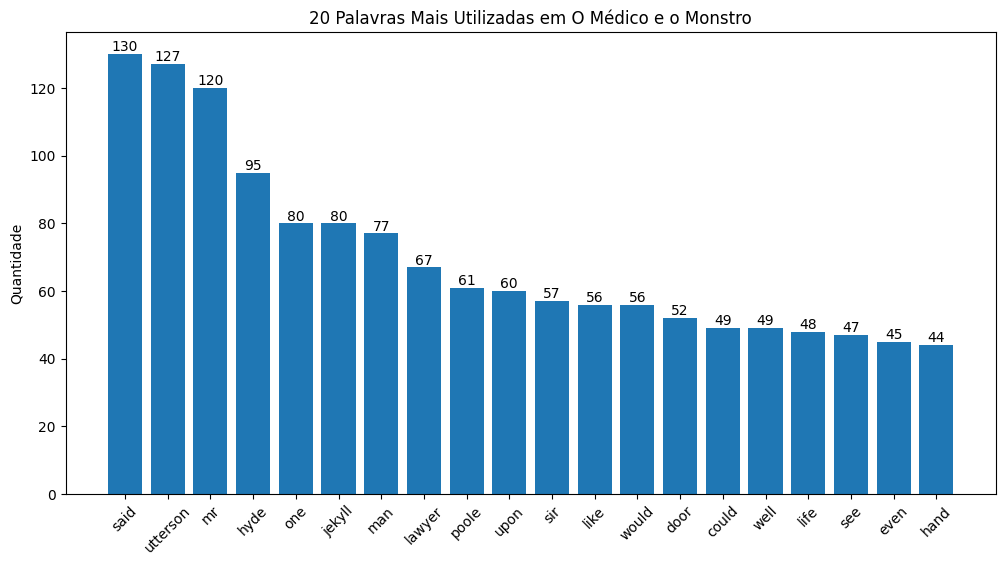

In [ ]:
# Contagem de Frequência das Palavras
word_counts = Counter(filtered_tokens)

# Pega as 20 Palavras que Mais Aparecem (Já sem Stopwords)
most_common_20 = word_counts.most_common(20)

# Comando novo que não conheciamos
words, counts = zip(*most_common_20)

# Plot
plt.figure(figsize=(12,6))
bars = plt.bar(words, counts)
plt.title("20 Palavras Mais Utilizadas em O Médico e o Monstro")
plt.bar_label(bars)
plt.xticks(rotation=45)
plt.ylabel("Quantidade")
plt.show()

### Representação em Wordcloud

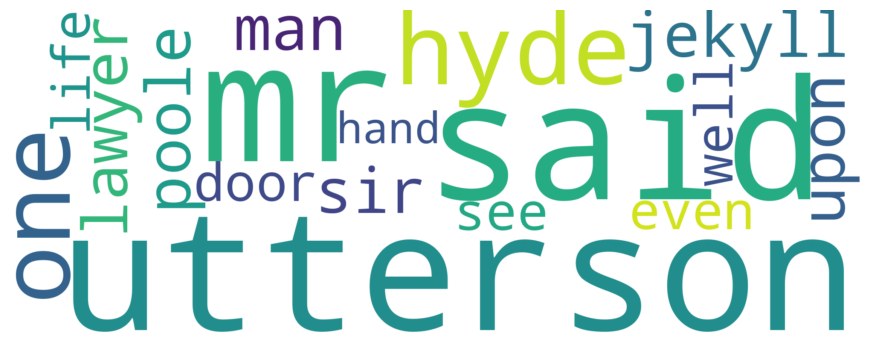

In [ ]:
list_most_common_20 = []
for i in most_common_20:
    list_most_common_20.append(i[0])

text = " ".join(list_most_common_20)
wordcloud = WordCloud(background_color="white",width=2000, height=800, collocations = False).generate(text)
fig = plt.figure(figsize=(11,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### Função para Calcular N-Gramas

In [ ]:
def ngrams_list(tokens, n):
    """Retorna a Lista dos N-Gramas como Strings 'w1 w2 ... wn'."""
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

### Bigramas

#### Tokens 1

In [ ]:
bigram_list = ngrams_list(filtered_tokens, 2)

bigram_counts = Counter(bigram_list)

most_common_10_bigrams = bigram_counts.most_common(10)

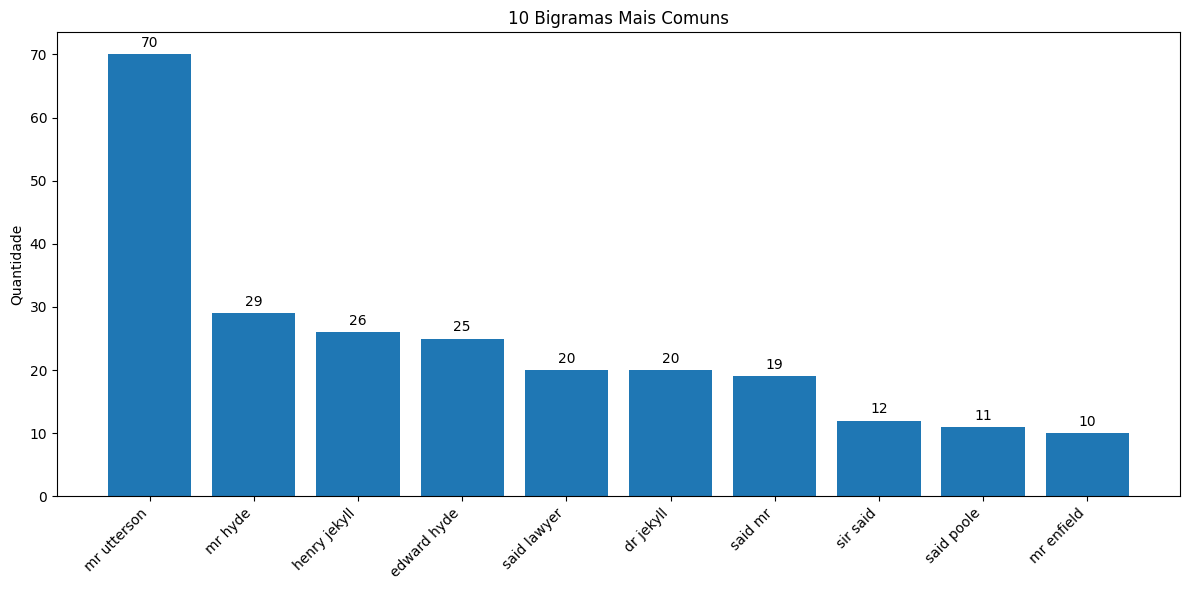

In [ ]:
labels, counts = zip(*most_common_10_bigrams)

plt.figure(figsize=(12,6))
bars = plt.bar(labels, counts)
plt.title("10 Bigramas Mais Comuns")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quantidade")
plt.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
plt.show()

#### Teste: Remoção de Palavras Pequenas (mr, sr, sir)

In [ ]:
# Remoção de Stopwords + Retirada de Palavras Pequenas
filtered_tokens_2 = [word for word in tokens if word not in stop_words and len(word)> 3]

#### Tokens 2

In [ ]:
bigram_list_2 = ngrams_list(filtered_tokens_2, 2)

bigram_counts_2 = Counter(bigram_list_2)

most_common_10_bigrams_2 = bigram_counts_2.most_common(10)

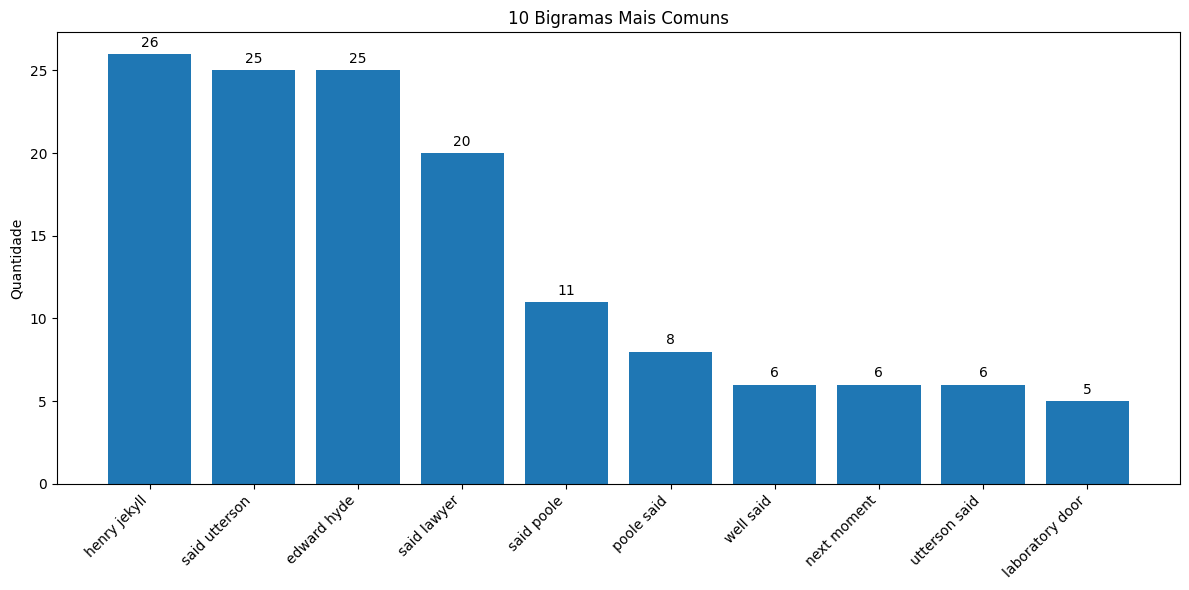

In [ ]:
labels_2, counts_2 = zip(*most_common_10_bigrams_2)

plt.figure(figsize=(12,6))
bars = plt.bar(labels_2, counts_2)
plt.title("10 Bigramas Mais Comuns")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quantidade")
plt.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
plt.show()

### Trigramas

#### Tokens 1

In [ ]:
trigram_list = ngrams_list(filtered_tokens, 3)

trigram_counts = Counter(trigram_list)

most_common_10_trigrams = trigram_counts.most_common(10)

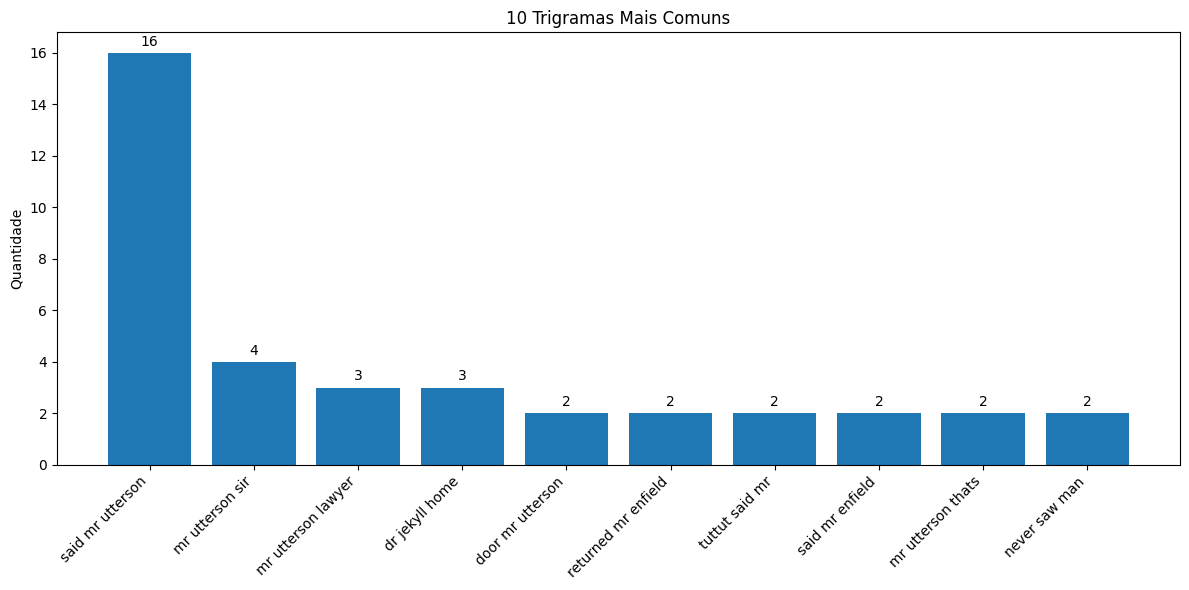

In [ ]:
t_labels, t_counts = zip(*most_common_10_trigrams)

plt.figure(figsize=(12,6))
bars = plt.bar(t_labels, t_counts)
plt.title("10 Trigramas Mais Comuns")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quantidade")
plt.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
plt.show()

#### Tokens 2

In [ ]:
trigram_list_2 = ngrams_list(filtered_tokens_2, 3)

trigram_counts_2 = Counter(trigram_list_2)

most_common_10_trigrams_2 = trigram_counts_2.most_common(10)

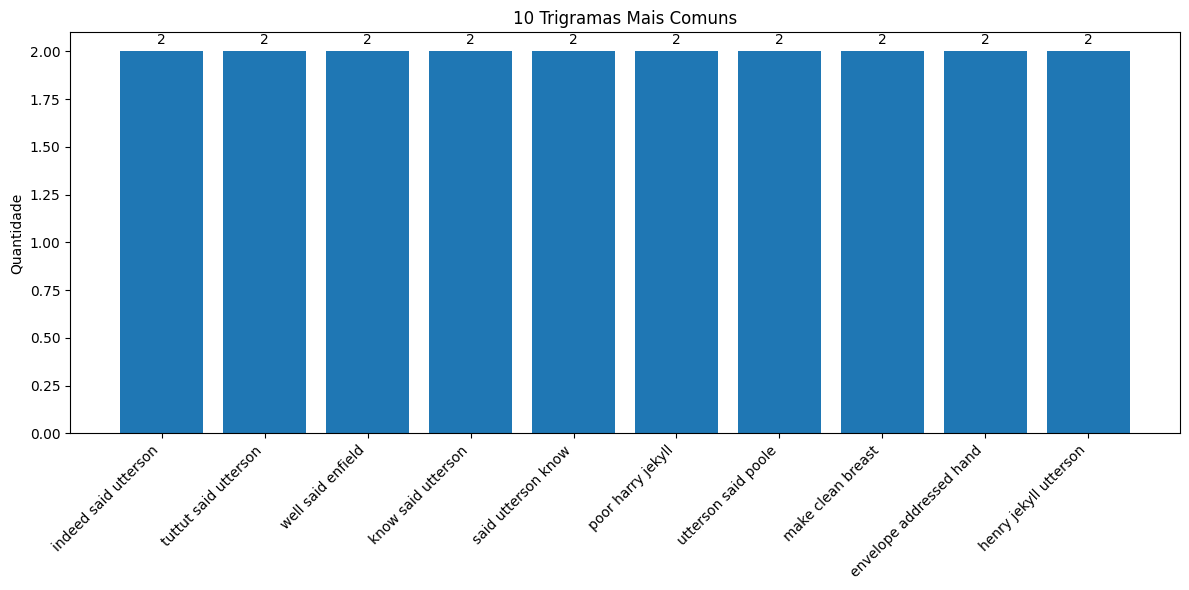

In [ ]:
t_labels, t_counts = zip(*most_common_10_trigrams_2)

plt.figure(figsize=(12,6))
bars = plt.bar(t_labels, t_counts)
plt.title("10 Trigramas Mais Comuns")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quantidade")
plt.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
plt.show()

## Análise de Concordância e Similaridade

In [ ]:
livro_text = nltk.Text(filtered_tokens)

### Palavras

#### Lawyer (Advogado)

In [ ]:
livro_text.concordance('lawyer')

Displaying 25 of 67 matches:
             story door mr utterson lawyer man rugged countenance never lighte
 visitors repair ravages mr enfield lawyer side bystreet came abreast entry fo
ueer street less ask good rule said lawyer studied place continued mr enfield 
es think returned enfield continued lawyer theres one point want ask want ask 
make bargain never refer heart said lawyer shake hands richard search mr hyde 
ument long lawyers eyesore offended lawyer lover sane customary sides life fan
others company little rambling talk lawyer led subject disagreeably preoccupie
heard since time amount information lawyer carried back great dark bed tossed 
e bidding figure two phases haunted lawyer night time dozed see glide stealthi
oon lights hours solitude concourse lawyer found chosen post mr hyde thought s
d suddenly louder turned end street lawyer looking forth entry could soon see 
e breath fear momentary though look lawyer face answered coolly enough name wa
enough name want see go

In [ ]:
livro_text.similar('lawyer')

last said side hard think know sort shall promise brings


#### Door (Porta)

In [ ]:
livro_text.concordance('door')

Displaying 25 of 52 matches:
                               story door mr utterson lawyer man rugged counte
o stories high showed window nothing door lower story blind forehead discolour
re marks prolonged sordid negligence door equipped neither bell knocker bliste
rmer lifted cane pointed ever remark door asked companion replied affirmative 
ing get money think carried us place door whipped key went presently came back
apocryphal man real life walk cellar door four morning come another mans chequ
ers youth blackmail house call place door consequence though even know far exp
ss lives square never asked theplace door said mr utterson sir delicacy reply 
nued mr enfield seems scarcely house door nobody goes one great gentleman adve
subjected stage delay ushered direct door diningroom dr lanyon sat alone wine 
d lay asleep dreaming smiling dreams door room would opened curtains bed pluck
time forward mr utterson began haunt door bystreet shops morning office hours 
y watchers inclination 

In [ ]:
livro_text.similar('door')

said looked soon


#### Man (Homem)

In [ ]:
livro_text.concordance('man')

Displaying 25 of 77 matches:
        story door mr utterson lawyer man rugged countenance never lighted smil
ar catholicity goodnature mark modest man accept friendly circle readymade hand
ard enfield distant kinsman wellknown man town nut crack many two could see sub
 empty churchtill last got state mind man listens listens begins long sight pol
 policeman saw two figures one little man stumping along eastward good walk gir
nough corner came horrible part thing man trampled calmly childs body left scre
s nothing hear hellish see wasnt like man like damned juggernaut gave viewhallo
 mine killing question next best told man could would make scandal make name st
arpies never saw circle hateful faces man middle kind black sneering coolnessfr
eman whole business looked apocryphal man real life walk cellar door four morni
ee feel said mr enfield yes bad story man fellow nobody could really damnable m
n fellow nobody could really damnable man person drew cheque pink proprieties c
ws call goo

In [ ]:
livro_text.similar('man')

utterson starting rule


### Bigramas

#### Dr Jekyll

In [ ]:
livro_text.concordance(['dr', 'jekyll'])

Displaying 20 of 20 matches:
veniently thought might admit find dr jekyll home replied mr hyde blowing key s
ressed elderly servant opened door dr jekyll home poole asked lawyer see mr utt
 poole presently returned announce dr jekyll gone saw mr hyde go old dissecting
ssectingroom door poole said right dr jekyll home quite right mr utterson sir r
clear transparency strange clauses dr jekyll quite ease fortnight later excelle
silence expense strain gaiety rule dr jekyll exception sat opposite side firea 
ing young hyde large handsome face dr jekyll grew pale lips came blackness eyes
began lie thickly close warmth sat dr jekyll looking deadly sick rise meet visi
 briefly enough writers benefactor dr jekyll long unworthily repaid thousand ge
 added lawyer servant entered note dr jekyll sir inquired clerk thought knew wr
influence withdrawn new life began dr jekyll came seclusion renewed relations f
 held trembling hand wish see hear dr jekyll said loud unsteady voice quite don
disconsolat

In [ ]:
livro_text.common_contexts(['dr', 'jekyll'])

No common contexts were found


#### Said Lawyer

In [ ]:
livro_text.concordance(['said', 'lawyer'])

Displaying 20 of 20 matches:
e queer street less ask good rule said lawyer studied place continued mr enfiel
us make bargain never refer heart said lawyer shake hands richard search mr hyd
e little hoarsely jekyll instance said lawyer never told cried mr hyde flush an
hall give light dining room thank said lawyer drew near leaned tall fender hall
mise cant pretend shall ever like said lawyer dont ask pleaded jekyll laying ha
ill yesterday well wish see rooms said lawyer woman began declare impossible be
re said heard diningroom one word said lawyer carew client want know mad enough
hing done returned lanyon ask see said lawyer surprised reply day utterson dead
 long thank god stay much indoors said lawyer whipping circulation like mr enfi
d ask mr enfield place really fit said lawyer goodnaturedly best thing stay spe
ething wrong take seat glass wine said lawyer take time tell plainly want know 
r utterson sir im afraid good man said lawyer explicit afraid ive afraid week r
d corner fl

In [ ]:
livro_text.common_contexts(['said', 'lawyer'])

utterson_man


#### Mr Hyde

In [ ]:
livro_text.concordance(['mr', 'hyde'])

Displaying 25 of 29 matches:
d lawyer shake hands richard search mr hyde evening mr utterson came home bache
anciful immodest hitherto ignorance mr hyde swelled indignation sudden turn kno
nate curiosity behold features real mr hyde could set eyes thought mystery woul
 concourse lawyer found chosen post mr hyde thought shall mr seek last patience
son stepped touched shoulder passed mr hyde think mr hyde shrank back hissing i
uched shoulder passed mr hyde think mr hyde shrank back hissing intake breath f
t admit find dr jekyll home replied mr hyde blowing key suddenly still without 
ied shall let see face asked lawyer mr hyde appeared hesitate upon sudden refle
mr utterson may useful yes returned mr hyde well met propos address gave number
d mr utterson common friends echoed mr hyde little hoarsely jekyll instance sai
stance said lawyer never told cried mr hyde flush anger think would lied come s
sappeared house lawyer stood awhile mr hyde left picture disquietude began slow
ting walked

In [ ]:
livro_text.common_contexts(['mr', 'hyde'])

No common contexts were found


### Trigramas

#### Dr Jekyll Home

In [ ]:
livro_text.common_contexts(['dr', 'jekyll', 'home'])

No common contexts were found


In [ ]:
livro_text.concordance(['dr', 'jekyll', 'home'])

Displaying 3 of 3 matches:
iently thought might admit find dr jekyll home replied mr hyde blowing key sud
sed elderly servant opened door dr jekyll home poole asked lawyer see mr utter
ctingroom door poole said right dr jekyll home quite right mr utterson sir rep


#### Poor Harry Jekyll

In [ ]:
livro_text.common_contexts(['poor', 'harry', 'jekyll'])

No common contexts were found


In [ ]:
livro_text.concordance(['poor', 'harry', 'jekyll'])

Displaying 1 of 1 matches:
awyer set homeward heavy heart poor harry jekyll thought mind misgives deep wat


#### Envelope Addressed Hand

In [ ]:
livro_text.common_contexts(['envelope', 'addressed', 'hand'])

No common contexts were found


In [ ]:
livro_text.concordance(['envelope', 'addressed', 'hand'])

Displaying 2 of 2 matches:
 melancholy candle drew set envelope addressed hand sealed seal dead friend pri
evening delivery registered envelope addressed hand colleague old schoolcompani


# Conclusão

A Análise serviu para mostrar que a forma narrativa do texto afeta a análise do texto e que, por conta disso, a presença do nome dos personagens de forma constante em bigramas e trigramas evidencia isso.